In [150]:
'''  
How to create a dataframe using pandas 

-> pd.DataFrame(data: dict[Any:Any])
-> info()
-> describe()
'''

'  \nHow to create a dataframe using pandas \n\n-> pd.DataFrame(data: dict[Any:Any])\n-> info()\n-> describe()\n'

In [151]:
import pandas as pd 
import numpy as np
data = {
    "Class": np.random.choice(["XI", "XII"], 10), 
    "Marks": np.random.randint(10,20, 10)
}
data

{'Class': array(['XII', 'XII', 'XII', 'XII', 'XI', 'XII', 'XI', 'XI', 'XII', 'XI'],
       dtype='<U3'),
 'Marks': array([11, 13, 18, 15, 19, 18, 12, 13, 19, 15], dtype=int32)}

In [152]:
df = pd.DataFrame(data = data)
df

,Class,Marks
0,XII,11
1,XII,13
2,XII,18
3,XII,15
4,XI,19
5,XII,18
6,XI,12
7,XI,13
8,XII,19
9,XI,15


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Class   10 non-null     object
 1   Marks   10 non-null     int32 
dtypes: int32(1), object(1)
memory usage: 252.0+ bytes


In [154]:
df.describe() # it works only for np.number classes (float, int)

,Marks
count,10.000000
mean,15.300000
std,3.020302
min,11.000000
25%,13.000000
50%,15.000000
75%,18.000000
max,19.000000


In [155]:
''' 
Adding a new column to our dataframe
'''
df["Id"] = list(np.random.randint(0,10,10)) 
df.head()

,Class,Marks,Id
0,XII,11,7
1,XII,13,8
2,XII,18,0
3,XII,15,7
4,XI,19,3


In [156]:
df.drop(columns=["Id"], axis=1, inplace=True) # inplace=True only if you want to modify existing dataframe object

In [157]:
df

,Class,Marks
0,XII,11
1,XII,13
2,XII,18
3,XII,15
4,XI,19
5,XII,18
6,XI,12
7,XI,13
8,XII,19
9,XI,15


In [158]:
column_lowercase = {column_name: column_name.lower() for column_name in list(df.columns)}

In [159]:
# df.rename(columns={"Class": "class", "Marks": "marks"}, inplace=True)
df.rename(mapper=column_lowercase, axis=1, inplace=True)

In [160]:
df

,class,marks
0,XII,11
1,XII,13
2,XII,18
3,XII,15
4,XI,19
5,XII,18
6,XI,12
7,XI,13
8,XII,19
9,XI,15


In [161]:
# mapper_dict = {}
# for ind in list(df.index):
#     if ind not in mapper_dict.keys():
#         mapper_dict[ind] = chr(65+ind) # 65+0 = 65 = A
# mapper_dict

mapper_dict = {ind:chr(65+ind) for ind in list(df.index)} #dict comprehention

In [162]:
print(mapper_dict)

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J'}


In [163]:
# df.rename(index={1: "A"}, inplace=True)
df.rename(mapper=mapper_dict, axis=0, inplace=True)
df

,class,marks
A,XII,11
B,XII,13
C,XII,18
D,XII,15
E,XI,19
F,XII,18
G,XI,12
H,XI,13
I,XII,19
J,XI,15


In [164]:
''' 
Transpose of dataframe
'''
new_df = df.T # this means changing existing dataframe for transpose using same object
new_df.head()

,A,B,C,D,E,F,G,H,I,J
class,XII,XII,XII,XII,XI,XII,XI,XI,XII,XI
marks,11,13,18,15,19,18,12,13,19,15


In [165]:
def swap_columns(column_A: str, column_B: str) -> list[str]:
    columns = list(new_df.columns) # I get my entire column list  
    index_A = columns.index(column_A) # 5
    index_B = columns.index(column_B) # 8
    temp = columns[index_A] # F
    columns[index_A] = columns[index_B] # I
    columns[index_B] = temp # F
    return columns

In [166]:
swap_column = swap_columns(column_A = 'F', column_B='I')
new_df[swap_column]

,A,B,C,D,E,I,G,H,F,J
class,XII,XII,XII,XII,XI,XII,XI,XI,XII,XI
marks,11,13,18,15,19,19,12,13,18,15


In [170]:
'''  
Just display top 3 columns of new_df dataframe
'''
new_df[list(new_df.columns)[0:10:2]]

,A,C,E,G,I
class,XII,XII,XI,XI,XII
marks,11,18,19,12,19


In [171]:
''' 
Pandas Indexing and Slicing
'''
data = {
    "Name": ["Alice", "bob", "Charlie", "David", "Eve"], 
    "Age": np.random.randint(20,30,5), 
    "City": ["New York", "Los Angeles", "London", "Tokyo", "Sydney"]
}

df = pd.DataFrame(data=data)
df.head()

,Name,Age,City
0,Alice,28,New York
1,bob,21,Los Angeles
2,Charlie,29,London
3,David,29,Tokyo
4,Eve,29,Sydney


In [174]:
'''Pandas DataFrame access via Indexing'''
name_df = df[["Age", "City"]]
name_df

,Age,City
0,28,New York
1,21,Los Angeles
2,29,London
3,29,Tokyo
4,29,Sydney


In [178]:
df["City"][0]

'New York'

In [ ]:
''' 
Label based indexing (loc, iloc)
1. .loc -> df.loc[row_indexes(to be mentioned in slicing way), column_indexes(to be mentioned in slicing way)]
2. .iloc
'''

In [184]:
df.loc[0:2, ["Name", "Age"]] # slicing in [list, numpy, pandas till iloc] only .loc take the end of slicing into consideration

,Name,Age
0,Alice,28
1,bob,21
2,Charlie,29


In [185]:
df.iloc[0:3, 0:3:2]

,Name,City
0,Alice,New York
1,bob,Los Angeles
2,Charlie,London


In [194]:
fetch_name = "Charlie"
df[df["Name"]==fetch_name][["Name", "Age"]]

,Name,Age
2,Charlie,29


In [ ]:
''' 
Matplotlib
'''

In [195]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


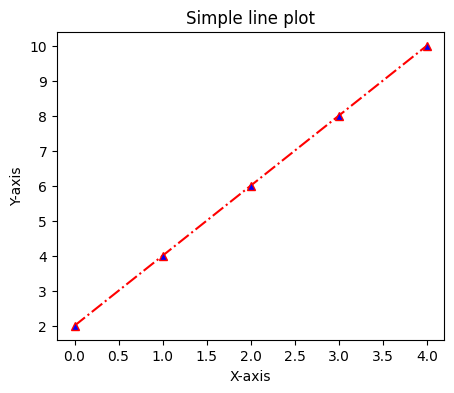

In [212]:
'''Line Plot'''
import matplotlib.pyplot as plt
x = [0,1,2,3,4]
y = [2,4,6,8,10]
plt.figure(figsize=(5,4))
plt.plot(x, y, marker='^', color='red', markerfacecolor='blue', linestyle='-.')
plt.title("Simple line plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

<Figure size 2000x1200 with 0 Axes>

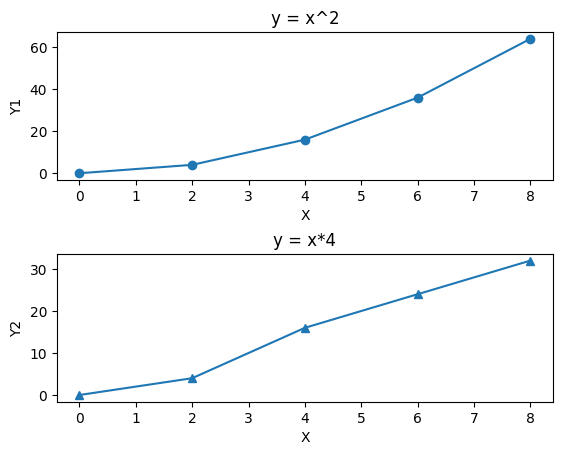

In [225]:
x = [0,2,4,6,8] 
y1 = [0,4,16,36,64]
y2 = [0,4,16,24,32]
''' 
        0                1
   |                |
   |  (fig1)        |   (fig2)
   |                |
(0)|                |
   |                |
   |                |
   |________________|________________
'''
plt.figure(figsize=(20,12))
fig, ax = plt.subplots(2,1)
ax[0].plot(x,y1,marker='o')
ax[0].set_title("y = x^2")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y1")

ax[1].plot(x,y2,marker='^')
ax[1].set_title("y = x*4")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y2")

plt.subplots_adjust(hspace=0.5)
plt.show()

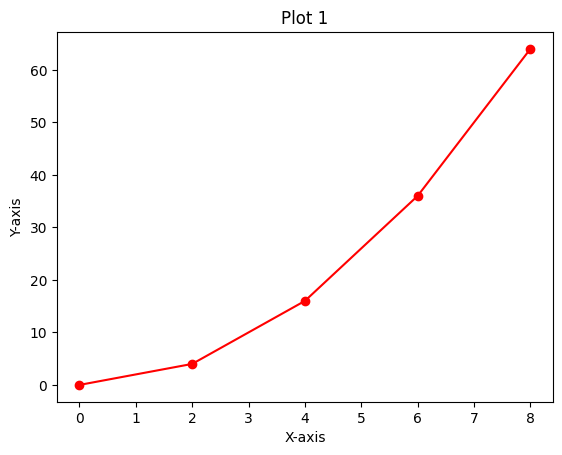

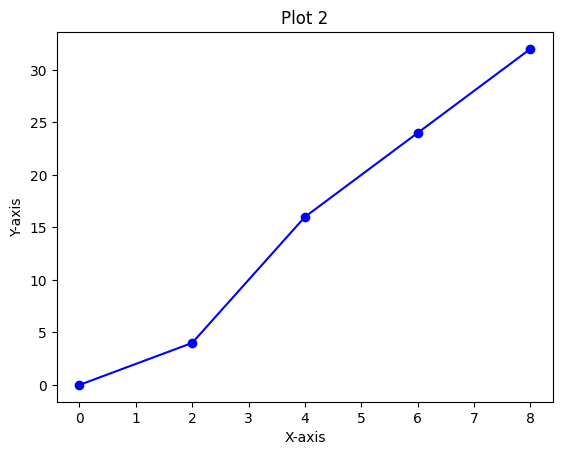

In [223]:
plt.plot(x,y1,marker="o",color="red")
plt.title("Plot 1")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()
plt.figure()
plt.plot(x,y2,marker="o",color="blue")
plt.title("Plot 2")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

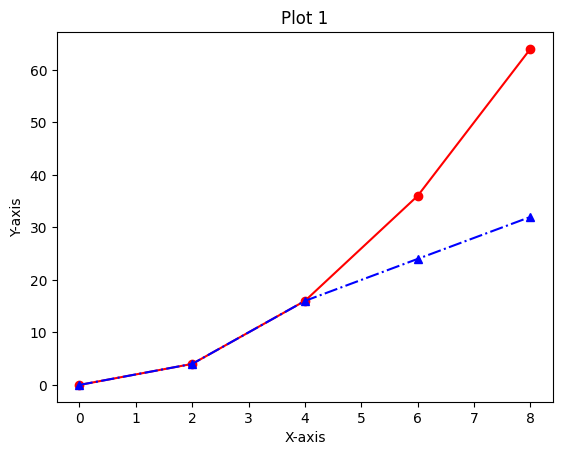

In [230]:
plt.plot(x,y1,marker="o",color="red")
plt.plot(x,y2,marker="^",color="blue", linestyle="-.")
plt.title("Plot 1")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

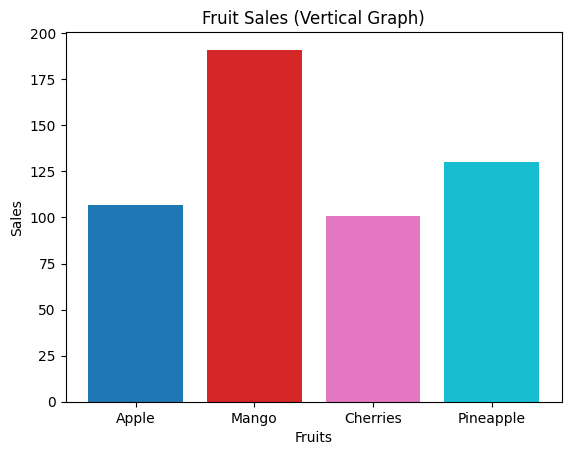

In [236]:
'''
Bar plot

plt.bar(x,height,width,bottom,align)
'''
fruits = ["Apple", "Mango", "Cherries", "Pineapple"]
sales = list(np.random.randint(100,200,4))
colors = plt.cm.tab10(np.linspace(0, 1, len(fruits)))
plt.bar(fruits, sales, color=colors)
plt.title("Fruit Sales (Vertical Graph)")
plt.xlabel("Fruits")
plt.ylabel("Sales")
plt.show()

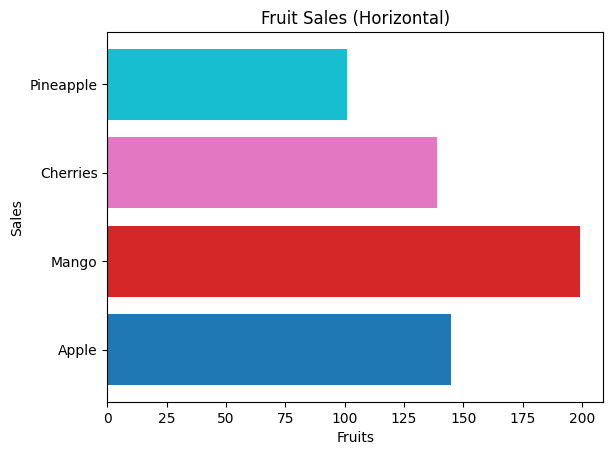

In [237]:
fruits = ["Apple", "Mango", "Cherries", "Pineapple"]
sales = list(np.random.randint(100,200,4))
colors = plt.cm.tab10(np.linspace(0, 1, len(fruits)))
plt.barh(fruits, sales, color=colors)
plt.title("Fruit Sales (Horizontal)")
plt.xlabel("Fruits")
plt.ylabel("Sales")
plt.show()

[29 21 26 23 28]
[22 23 21 21 25]


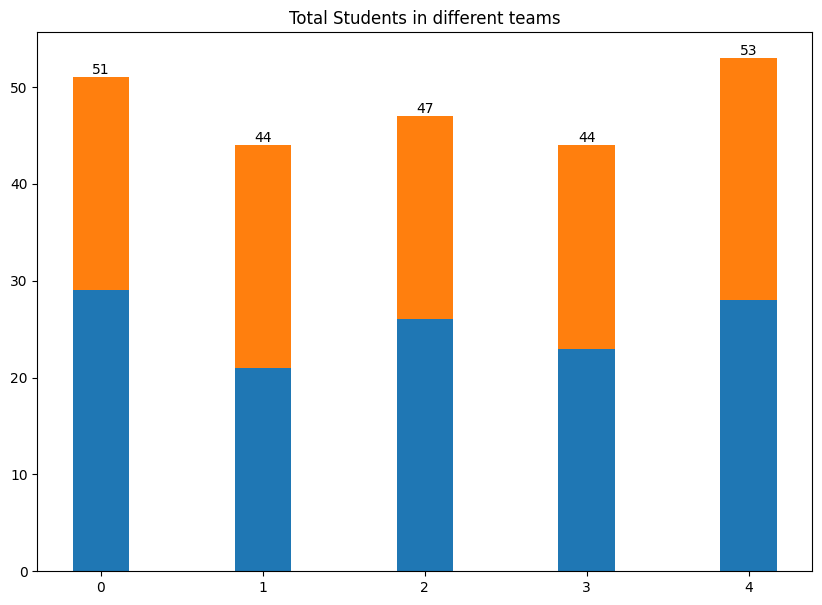

In [256]:
''' 
stacked bar plot
'''
N = 5
np.random.seed()
boys = np.random.randint(20,30,N) # [.. .. .. .. ..]
girl = np.random.randint(20,30,N) # [.. .. .. .. ..]
print(boys)
print(girl)
ind = np.arange(N)
width = 0.35 
fig = plt.subplots(figsize=(10,7))
p1 = plt.bar(ind, boys, width)
p2 = plt.bar(ind, girl, width, bottom=boys)

for rect, bottom_height in zip(p2, boys):
    total = rect.get_height() + bottom_height # vertical length of my bar
    plt.text(
        x = rect.get_x() + rect.get_width()/2, # this will give width of my bar
        y = total,
        s = str(total),
        ha='center',
        va='bottom'
    )
plt.title("Total Students in different teams")
plt.show()

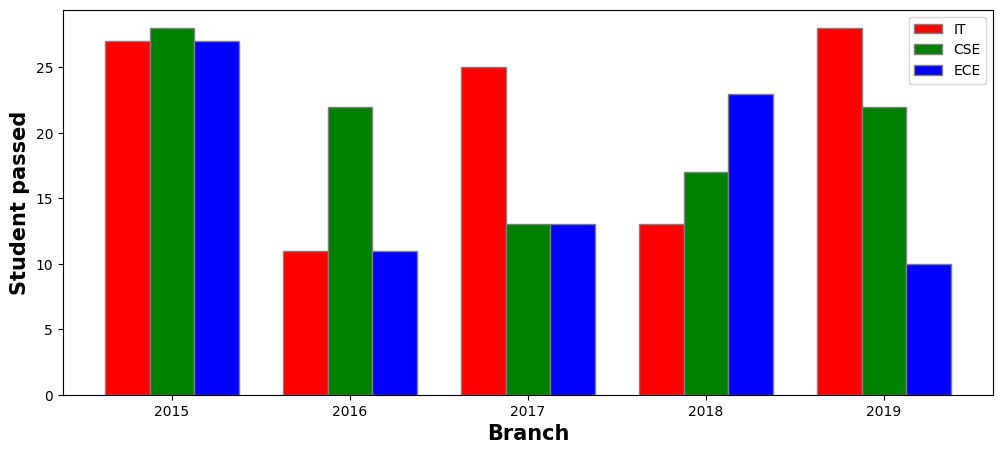

In [ ]:
''' 
Multiple bar plot
'''
barWidth = 0.25  # 0.25 * 100 pixel = 25 pixel 
fig = plt.subplots(figsize=(12,5))
IT = np.random.randint(10,30,5) # 10   [..(0-25pixel) ..(100-125pixel) ..() .. ..]
CSE = np.random.randint(10,30,5) # 20  [..(25-50pixel) ..(125-150 pixel) .. .. ..]
ECE = np.random.randint(10,30,5) # 15  [..(50-75 pixel) ..(150-175pixel) .. .. ..]

br1 = np.arange(len(IT)) # 0, 1, 2, 3, 4
br2 = [x+barWidth for x in br1] # 0.25, 1.25, 2.25, 3.25, 4.25
br3 = [x+barWidth for x in br2] # 0.5, 1.5, 2.5, 3.5, 4.5

plt.bar(br1, IT, color='r', width=barWidth, edgecolor='grey', label='IT')
plt.bar(br2, CSE, color='g', width=barWidth, edgecolor='grey', label='CSE')
plt.bar(br3, ECE, color='b', width=barWidth, edgecolor='grey', label='ECE')

plt.xlabel('Branch', fontweight="bold", fontsize=15)
plt.ylabel('Student passed', fontweight="semibold", fontsize=15)

plt.xticks([r+barWidth for r in range(len(IT))], [str(2015+i) for i in range(len(IT))])

plt.legend()
plt.show()
